# AMTDB Metadata Linkage

Link our extracted ND gene sequences with temporal and geographic provenance from the local AMTDB metadata file.

**Source**: `pilot_analysis/data/amtdb_metadata_full.csv`

**Goal**: Create a clean metadata file that maps sample IDs to:
- Temporal data (year_from, year_to, date BP)
- Geographic data (lat, lon, country)
- Archaeological context (group, epoch)
- Genetic classification (mtDNA haplogroup)

In [1]:
import pandas as pd
import numpy as np
import pickle
from pathlib import Path

DATA_DIR = Path(".")
PARENT_DIR = Path("..")  # pilot_analysis/data/

# Local metadata file
METADATA_CSV = PARENT_DIR / "amtdb_metadata_full.csv"

In [2]:
# Load our extracted ND gene sequences to get sample IDs
with open(PARENT_DIR / "amtdb_nd_seqs.pkl", "rb") as f:
    amtdb_nd_seqs = pickle.load(f)

our_sample_ids = set(amtdb_nd_seqs["ND1"].keys())
print(f"Extracted ND gene sequences: {len(our_sample_ids)} samples")

# Load local metadata file
df_meta_raw = pd.read_csv(METADATA_CSV)
print(f"Metadata file: {len(df_meta_raw)} samples, {len(df_meta_raw.columns)} columns")
print(f"Columns: {list(df_meta_raw.columns)}")

Extracted ND gene sequences: 1374 samples
Metadata file: 2541 samples, 11 columns
Columns: ['name', 'group', 'epoch', 'country', 'sex', 'year_from', 'year_to', 'haplogroup', 'lat', 'lon', 'fasta_url']


In [3]:
# Match samples between our sequences and metadata
metadata_ids = set(df_meta_raw["name"].astype(str))
matched_ids = our_sample_ids & metadata_ids

print(f"Sample overlap:")
print(f"  Our sequences: {len(our_sample_ids)}")
print(f"  Metadata file: {len(metadata_ids)}")
print(f"  Matched: {len(matched_ids)} ({100*len(matched_ids)/len(our_sample_ids):.1f}%)")

# Filter metadata to matched samples
df_meta = df_meta_raw[df_meta_raw["name"].astype(str).isin(our_sample_ids)].copy()
df_meta = df_meta.rename(columns={"name": "sample_id"})
print(f"\nFiltered metadata: {len(df_meta)} samples")
df_meta.head()

Sample overlap:
  Our sequences: 1374
  Metadata file: 2541
  Matched: 1374 (100.0%)

Filtered metadata: 1374 samples


,sample_id,group,epoch,country,sex,year_from,year_to,haplogroup,lat,lon,fasta_url
0,I5207,LBK,Neolithic,Austria,M,-5500,-4500,H67,48.580002,16.469999,/static_md5/data/fasta/I5207.fa
1,DA125,IAST,Iron Age,Kazakhstan,M,140,160,U2e2a1,42.593056,68.050552,/static_md5/data/fasta/DA125.fa
3,I3596,BBC,Copper Age,Germany,M,-2300,-2150,H+16129,48.883301,12.533200,/static_md5/data/fasta/I3596.fa
4,I6590,BBC,Copper Age,Germany,F,-2500,-2000,X2c1,48.841000,12.750000,/static_md5/data/fasta/I6590.fa
5,I5208,LBK,Neolithic,Austria,F,-5500,-4500,K1b1a,48.580002,16.469999,/static_md5/data/fasta/I5208.fa


In [ ]:
# Process temporal data
# year_from/year_to are in calendar years (negative = BCE, positive = CE)
df_meta["year_from"] = pd.to_numeric(df_meta["year_from"], errors="coerce")
df_meta["year_to"] = pd.to_numeric(df_meta["year_to"], errors="coerce")

# Sanity check: flag samples with implausible dates
# Ancient DNA should not have dates after ~1950 CE (the BP reference point)
MAX_VALID_YEAR = 1950
implausible = df_meta["year_to"] > MAX_VALID_YEAR
if implausible.any():
    print(f"WARNING: {implausible.sum()} samples have year_to > {MAX_VALID_YEAR}:")
    print(df_meta.loc[implausible, ["sample_id", "year_from", "year_to", "epoch"]])
    print(f"\nSetting date fields to NaN for these samples (preserving other metadata)...")
    # Set date fields to NaN instead of filtering out entirely
    df_meta.loc[implausible, ["year_from", "year_to"]] = np.nan

# Calculate midpoint date
df_meta["date_mid"] = (df_meta["year_from"] + df_meta["year_to"]) / 2

# Calculate date uncertainty (half-range)
df_meta["date_uncertainty"] = (df_meta["year_to"] - df_meta["year_from"]) / 2

# Convert to years before present (BP, where present = 1950 CE)
df_meta["date_bp"] = 1950 - df_meta["date_mid"]

# Summary
valid_dates = df_meta["date_bp"].notna()
print("\nTemporal data summary:")
print(f"  Samples with valid dates: {valid_dates.sum()} / {len(df_meta)}")
print(f"  Calendar range: {df_meta['year_from'].min():.0f} to {df_meta['year_to'].max():.0f}")
print(f"  BP range: {df_meta['date_bp'].min():.0f} to {df_meta['date_bp'].max():.0f} years BP")
print(f"  Mean uncertainty: {df_meta['date_uncertainty'].mean():.0f} years")

In [5]:
# Validate geographic data
df_meta["lat"] = pd.to_numeric(df_meta["lat"], errors="coerce")
df_meta["lon"] = pd.to_numeric(df_meta["lon"], errors="coerce")

has_coords = df_meta["lat"].notna() & df_meta["lon"].notna()
print(f"Samples with coordinates: {has_coords.sum()} / {len(df_meta)} ({100*has_coords.mean():.1f}%)")

print(f"\nCoordinate ranges:")
print(f"  Latitude: {df_meta['lat'].min():.2f} to {df_meta['lat'].max():.2f}")
print(f"  Longitude: {df_meta['lon'].min():.2f} to {df_meta['lon'].max():.2f}")

print(f"\nCountry distribution (top 10):")
print(df_meta["country"].value_counts().head(10))

Samples with coordinates: 1369 / 1371 (99.9%)

Coordinate ranges:
  Latitude: 31.79 to 61.65
  Longitude: -9.30 to 105.18

Country distribution (top 10):
country
Spain             341
Great Britain     155
Germany           123
Hungary            84
Poland             79
Kazakhstan         78
Czech Republic     66
Ukraine            40
Serbia             39
Italy              33
Name: count, dtype: int64


In [6]:
# Epoch and group distribution
print("Epoch distribution:")
print(df_meta["epoch"].value_counts())

print(f"\nArchaeological groups: {df_meta['group'].nunique()} unique")
print(f"mtDNA haplogroups: {df_meta['haplogroup'].nunique()} unique")

Epoch distribution:
epoch
Copper Age        355
Neolithic         297
Bronze Age        244
Middle Ages       230
Iron Age          129
Mesolithic         72
Classical Age      34
Epipaleolithic      6
Modern Era          3
Epigravettian       1
Name: count, dtype: int64

Archaeological groups: 81 unique
mtDNA haplogroups: 551 unique


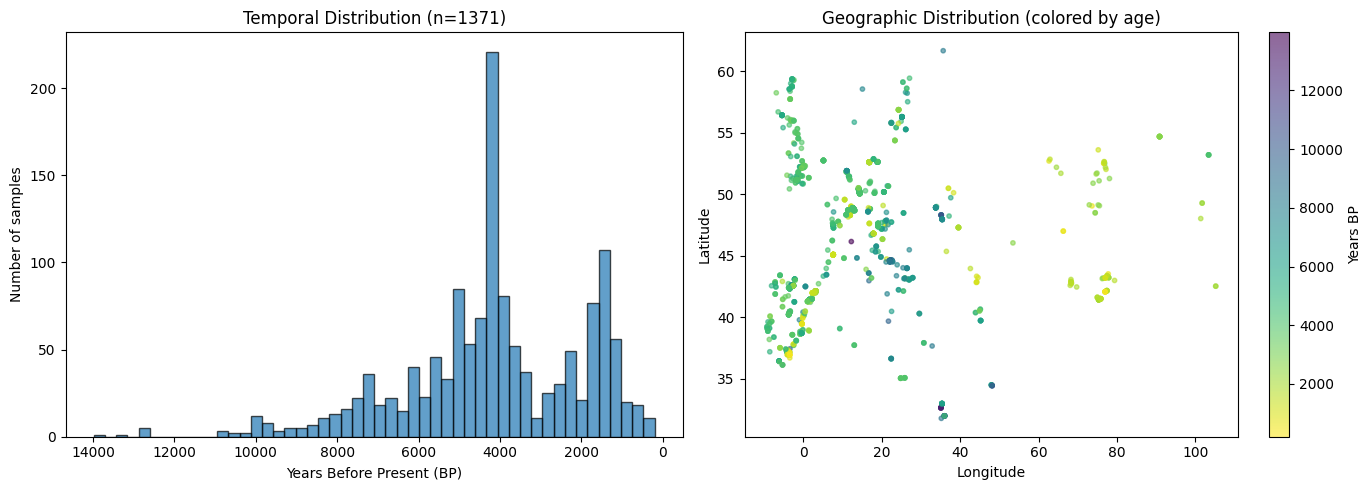

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Temporal distribution
ax = axes[0]
ax.hist(df_meta["date_bp"].dropna(), bins=50, edgecolor="black", alpha=0.7)
ax.set_xlabel("Years Before Present (BP)")
ax.set_ylabel("Number of samples")
ax.set_title(f"Temporal Distribution (n={len(df_meta)})")
ax.invert_xaxis()  # Older dates on left

# Geographic distribution
ax = axes[1]
scatter = ax.scatter(
    df_meta["lon"], df_meta["lat"],
    c=df_meta["date_bp"], cmap="viridis_r",
    alpha=0.6, s=10
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Geographic Distribution (colored by age)")
plt.colorbar(scatter, ax=ax, label="Years BP")

plt.tight_layout()
plt.show()

In [12]:
# Save linked metadata aligned with amtdb_nd_seqs samples
OUTPUT_CSV = DATA_DIR / "amtdb_metadata_linked.csv"

# Select columns for output
cols_out = [
    "sample_id", "group", "epoch", "country", "sex",
    "year_from", "year_to", "date_mid", "date_bp", "date_uncertainty",
    "lat", "lon", "haplogroup"
]
cols_out = [c for c in cols_out if c in df_meta.columns]
df_out = df_meta[cols_out].copy()

# Reindex to match exactly the samples in amtdb_nd_seqs (sorted alphabetically)
df_out = df_out.set_index("sample_id")
df_out = df_out.reindex(sorted(our_sample_ids))
df_out = df_out.reset_index().rename(columns={"index": "sample_id"})

# Report coverage
has_dates = df_out["date_bp"].notna()
has_metadata = df_out["group"].notna()  # proxy for having any metadata
print(f"Metadata output:")
print(f"  Total samples: {len(df_out)} (matches amtdb_nd_seqs)")
print(f"  With metadata: {has_metadata.sum()}")
print(f"  With valid dates: {has_dates.sum()}")
print(f"  Missing dates only: {(has_metadata & ~has_dates).sum()}")
print(f"  Missing all metadata: {(~has_metadata).sum()}")

df_out.to_csv(OUTPUT_CSV, index=False)
print(f"\nSaved to {OUTPUT_CSV}")
df_out.head()

Metadata output:
  Total samples: 1374 (matches amtdb_nd_seqs)
  With metadata: 1371
  With valid dates: 1371
  Missing dates only: 0
  Missing all metadata: 3

Saved to amtdb_metadata_linked.csv


,sample_id,group,epoch,country,sex,year_from,year_to,date_mid,date_bp,date_uncertainty,lat,lon,haplogroup
0,20036,NENE,Neolithic,Turkey,U,-6450.0,-6380.0,-6415.0,8365.0,35.0,37.666668,32.828056,U3b
1,AED_106,MAGe,Middle Ages,Germany,M,480.0,510.0,495.0,1455.0,15.0,48.292400,11.905300,V3
2,AED_1108,MAGe,Middle Ages,Germany,F,355.0,532.0,443.5,1506.5,88.5,48.292400,11.905300,U4a2a
3,AED_1119,MAGe,Middle Ages,Germany,F,510.0,530.0,520.0,1430.0,10.0,48.292400,11.905300,W1e1a
4,AED_1135,MAGe,Middle Ages,Germany,F,480.0,530.0,505.0,1445.0,25.0,48.292400,11.905300,H60a


In [16]:
# Final summary
print("=" * 60)
print("AMTDB METADATA LINKAGE SUMMARY")
print("=" * 60)
print(f"Samples in amtdb_nd_seqs: {len(our_sample_ids)}")
print(f"Samples in output: {len(df_out)}")
print(f"Samples with valid dates: {has_dates.sum()}")
print(f"\nTemporal range (valid samples):")
print(f"  Oldest: {df_out['date_bp'].max():.0f} BP")
print(f"  Youngest: {df_out['date_bp'].min():.0f} BP")
print(f"\nGeographic coverage:")
print(f"  Countries: {df_out['country'].nunique()}")
print(f"  Epochs: {df_out['epoch'].nunique()}")
print(f"\nGenetic diversity:")
print(f"  mtDNA haplogroups: {df_out['haplogroup'].nunique()}")
print(f"\nOutput: {OUTPUT_CSV}")

AMTDB METADATA LINKAGE SUMMARY
Samples in amtdb_nd_seqs: 1374
Samples in output: 1374
Samples with valid dates: 1371

Temporal range (valid samples):
  Oldest: 13980 BP
  Youngest: 200 BP

Geographic coverage:
  Countries: 34
  Epochs: 10

Genetic diversity:
  mtDNA haplogroups: 551

Output: amtdb_metadata_linked.csv
